# COM6018 Assignment 2

Copyright © 2023 Jon Barker, University of Sheffield. All rights reserved.
3rd December 2023. v1.1
Which Way Up?
Due: 15:00, Friday 15th December 2023
Table of Contents

• 1. Introduction

• 2. The Data

• 3. The Task

• 4. Additional Rules

• 5. Hints on How to Proceed

• 6. Assessment

• 7. Submission

## 1. Introduction

The task is to build a classifier that can determine the orientation of an image of part of a face.
It must take a square region from a face image and report whether it is the right way up,
rotated 90-degree right, rotated 90-degree left or upside down. The square regions are of size
90, 50 or 30 pixels and are taken from original images of complete face that are 94 pixels
wide by 125 pixels high.
Further details of the data, the task, the assessment criteria and the submission process are
given below.

## 2. The Data
You will be provided with training and evaluation datasets that have been constructed from
the 'Labeled Faces in the Wild' dataset. This is the same data that was used in the lab for the
person identification task.

## 2.1. The training data
The training data consists of 10,803 images representing 80% of the people in the full
dataset. They are stored in a file train.full.joblib (size 484 MB) that you will be able to
download. You are also provided with a file train.small.joblib that contains a subset of
1/4 of the images that you might find useful to use during development (size 112 MB).
The data can be loaded with,

In [ ]:
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [9]:
images, person_ids = joblib.load('train.full.joblib')
images_small, person_ids_small = joblib.load('train.small.joblib')

The images variable will be a NumPy array with shape (10803, 125, 94), i.e., 10803 images of
size 125 by 94 pixels. The person_ids will be a NumPy array of shape (10803,) containing
each image's person ID from the original database. This is not relevant to the task but might
be useful for debugging.

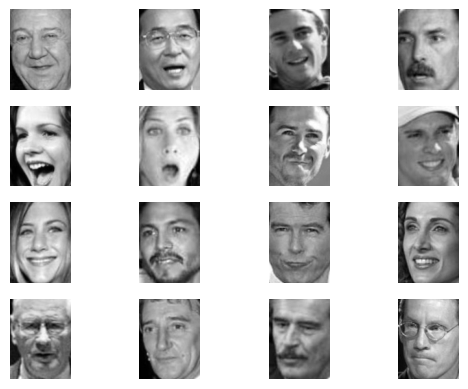

In [10]:
for index in range(16):
    plt.subplot(4, 4, index + 1)
    plt.imshow(images_small[index], cmap='gray')
    plt.axis('off')

# 2.2. The evaluation data
The evaluation sets consist of 2,000 examples of square sub-images with sides of length 90,
50 or 30 pixels. These have been sampled from 10% of the people in the dataset that do not
occur in the training data set. These sub-images have then been rotated by 0, 90, 180 and
270 degrees so that there are an equal number of each orientation (i.e., 500 examples of each
orientation).

 The sub-images have been reshaped into feature vectors of length 8100, 2500 or 900 pixels
respectively for the 90-, 50- and 30-pixel sub-images and stored in the rows of a data matrix,
x_test , i.e., the matrices are of size 2000 x 8100, 2000 x 2500 or 2000 x 900 respectively for
the 2000 sub-images of size 90, 50 and 30 pixels. The corresponding labels are stored in the
vector y_test of size 2000 x 1. The labels are integers in the range 0 to 3, where 0
represents the right way up, 1 represents a 90-degree rotation to the left, 2 represents a
180-degree rotation and 3 represents a 90-degree rotation to the right.

The evaluation data is stored in the file eval1.joblib which you have been provided with.
You can load this file with,

In [ ]:
import joblib
data = joblib.load('eval1.joblib')
print(data)

In [12]:
data = {
'90': {
'x_test': #<2000 x 8100 matrix of 90 pixel sub-images>,
'y_test': #<2000 x 1 vector of labels>
},
'50': {
'x_text': #<2000 x 2500 matrix of 50 pixel sub-images>,
'y_test': #<2000 x 1 vector of labels>
},
'30': {
'x_test': #<2000 x 900 matrix of 30 pixel sub-images>,
'y_test': #<2000 x 1 vector of labels>
}
}

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2145138378.py, line 3)

In [11]:
x_test = data['90']['x_test']
y_test = data['90']['y_test']

KeyError: '90'

## 2.3. The baseline models
You are provided with example 'baseline' models that use PCA and 1-nearest neighbour
classifier. These models are called knn.30.joblib , knn.50.joblib and knn.90.joblib .
The performance of these models on the evaluation data is as follows:

Sub-image size % Correct

30 47.6

50 71.7

90 93.2
This is the performance that you should aim to beat.

# 3. The Task
### 3.1 Developing a Classification Model
You are asked to make three separate scikit-learn models which can be used to classify the
30, 50 and 90-pixel sub-images respectively. These models should be saved with joblib to
files called model.30.joblib , model.50.joblib and model.90.joblib which you will
submit. You are provided with a script evaluate.py which you can use to check that your
models work, and which will be used to assess your system.

The evaluation script can be run with,

python evaluate.py <MODEL_FILE_NAME> <IMAGE_SIZE>

So you can test your model files with,

python evaluate.py model.90.joblib 90
python evaluate.py model.50.joblib 50
python evaluate.py model.30.joblib 30

Your model files should be created by a Python script called train.py that you will need to
write and submit. It will take the training data as input and save the trained model to a joblib
file. The train.py script should be run wit

python train.py <TRAINING_DATA_FILE_NAME> <MODEL_FILE_NAME> <IMAGE_SIZE>

So, for example, you can train your model files with

python train.py train.full.joblib model.90.joblib 90
python train.py train.full.joblib model.50.joblib 50
python train.py train.full.joblib model.30.joblib 30


